# 06 · Khoảng ngắt bên trong stay-point

**Câu hỏi:** Khi một stay-point chứa khoảng ngắt dài (thiết bị ngừng ghi > 20 phút), người dùng **ở yên tại chỗ** (ví dụ vào trong nhà nên mất GPS), hay **đã rời đi rồi quay lại**? Nếu thường rời đi thì dwell-time bị tính dư, và cần cắt stay-point tại khoảng ngắt dài.

**Quyết định:**
- **Không cắt** stay-point tại khoảng ngắt bên trong.
- Mỗi `StayPoint` mang cả `duration_minutes` (từ lúc đến tới lúc đi) và `observed_minutes` (bỏ các khoảng ngắt > 20 phút), để bước phía sau kiểm tra được độ nhạy.

**Khái niệm:**
- *Khoảng ngắt* là thời gian giữa hai điểm GPS liên tiếp. Ở đây chỉ xét khoảng ngắt > 20 phút (`max_gap_seconds`, notebook 03).
- *Khoảng ngắt bên trong stay-point* là khoảng ngắt mà điểm ngay trước và ngay sau đều thuộc cửa sổ của một stay-point (trong vùng 200 m).

**Stay-point:** chế độ CENTROID, 30 phút / 200 m, chạy **riêng từng file `.plt`**. Các file là những lần ghi độc lập; nối lại sẽ gộp các lần ghi cách nhau nhiều ngày hoặc nhiều năm, ví dụ stay-point "4 năm" của user 055.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK = "06_gaps_inside_staypoints"
DATA_DIR = Path("../data/raw")
OUT_DIR = Path("outputs") / NOTEBOOK
FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR = (OUT_DIR / d for d in ("figures", "tables", "cache", "maps"))
for d in (FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(Path("../src").resolve()))
from gps.data.processing import _haversine_vectorized
from gps.features.stay_point import DistanceMode, StayPointDetector

USERS_DIR = Path("../data/processed/users")
GAP_S = 1200            # max_gap_seconds (notebook 03)
MIN_STAY_MIN = 30       # stay-point time threshold


def load_labels(user_dir: Path) -> pd.DataFrame | None:
    """labels.txt of one user (EDA only - production does not use transport labels)."""
    path = user_dir / "labels.txt"
    if not path.exists():
        return None
    df = pd.read_csv(path, sep="\t", skiprows=1, header=None, names=["start", "end", "mode"])
    df["start_datetime"] = pd.to_datetime(df["start"], format="%Y/%m/%d %H:%M:%S", errors="coerce")
    df["end_datetime"] = pd.to_datetime(df["end"], format="%Y/%m/%d %H:%M:%S", errors="coerce")
    return df.dropna(subset=["start_datetime", "end_datetime"])[["start_datetime", "end_datetime", "mode"]]

## 1. Stay-point của toàn bộ 182 user (chạy riêng từng file)
Chạy tuần tự mất khoảng 40 phút, nên kết quả được cache. Muốn tính lại trên dữ liệu mới nhất thì xoá `cache/staypoints.parquet`.

In [2]:
STAYS_PATH = CACHE_DIR / "staypoints.parquet"
detector = StayPointDetector(time_threshold_minutes=MIN_STAY_MIN, distance_threshold_meters=200,
                             distance_mode=DistanceMode.CENTROID, max_gap_hours=None)
if STAYS_PATH.exists():
    stays = pd.read_parquet(STAYS_PATH)
else:
    rows = []
    user_files = sorted(USERS_DIR.glob("user_*.parquet"))
    for k, path in enumerate(user_files, start=1):
        uid = path.stem.split("_")[1]
        print(f"\r[{k}/{len(user_files)}] user {uid}", end="", flush=True)
        df = pd.read_parquet(path, columns=["source_file", "datetime", "lat", "lon", "altitude_m"])
        for fname, f_df in df.groupby("source_file"):
            for sp in detector.detect(f_df.sort_values("datetime")):
                rows.append({"user_id": uid, "source_file": fname, "lat": sp.lat, "lon": sp.lon,
                             "arrival": sp.arrival_time, "departure": sp.departure_time,
                             "duration_min": sp.duration_minutes, "observed_min": sp.observed_minutes,
                             "n_points": sp.num_points})
    print()
    stays = pd.DataFrame(rows)
    stays.to_parquet(STAYS_PATH)

print(f"Stay-points: {len(stays):,} | users with stay-points: {stays['user_id'].nunique()}")
print(f"Total dwell-time: {stays['duration_min'].sum() / 60:,.0f} h, of which observed: "
      f"{stays['observed_min'].sum() / stays['duration_min'].sum():.1%}")

Stay-points: 12,856 | users with stay-points: 168
Total dwell-time: 22,813 h, of which observed: 34.8%


## 2. Các khoảng ngắt > 20 phút bên trong stay-point
Mỗi dòng là một khoảng ngắt, gồm: `t0` (điểm cuối trước khi ngắt), `t1` (điểm đầu sau khi ngắt), độ dài, `jump_m` (khoảng cách giữa hai điểm đó) và giờ địa phương lúc bắt đầu ngắt.

In [3]:
GAPS_PATH = CACHE_DIR / "instay_gaps.parquet"
if GAPS_PATH.exists():
    gaps = pd.read_parquet(GAPS_PATH)
else:
    rows = []
    for uid, u_stays in stays.groupby("user_id"):
        df = pd.read_parquet(USERS_DIR / f"user_{uid}.parquet",
                             columns=["source_file", "datetime", "timestamp_local", "lat", "lon"])
        for fname, f_stays in u_stays.groupby("source_file"):
            f = df[df["source_file"] == fname].sort_values("datetime")
            ts = f["datetime"].to_numpy("datetime64[ns]")
            loc = f["timestamp_local"].to_numpy()
            lat, lon = f["lat"].to_numpy(), f["lon"].to_numpy()
            for stay_id, s in f_stays.iterrows():
                a = np.searchsorted(ts, np.datetime64(s["arrival"]), "left")
                b = np.searchsorted(ts, np.datetime64(s["departure"]), "right")
                g = np.diff(ts[a:b]) / np.timedelta64(1, "s")
                for k in np.flatnonzero(g > GAP_S):
                    i = a + k
                    rows.append({"user_id": uid, "stay_id": stay_id, "t0": ts[i], "t1": ts[i + 1],
                                 "gap_s": float(g[k]), "hour_local": pd.Timestamp(loc[i]).hour,
                                 "jump_m": float(_haversine_vectorized(lat[i], lon[i], lat[i + 1], lon[i + 1]))})
    gaps = pd.DataFrame(rows)
    gaps.to_parquet(GAPS_PATH)

BANDS = [GAP_S, 3600, 2 * 3600, 3 * 3600, 6 * 3600, np.inf]
BAND_LABELS = ["20m-1h", "1-2h", "2-3h", "3-6h", ">6h"]
gaps["band"] = pd.cut(gaps["gap_s"], BANDS, labels=BAND_LABELS)
print(f"Stay-points with >= 1 gap over 20 min: {gaps['stay_id'].nunique():,}/{len(stays):,}")
print(f"Gaps over 20 min inside stay-points: {len(gaps):,}")

Stay-points with >= 1 gap over 20 min: 8,549/12,856
Gaps over 20 min inside stay-points: 9,842


## 3. Vị trí trước và sau khoảng ngắt
`jump_m` nhỏ nghĩa là khi có tín hiệu lại, người dùng vẫn ở đúng chỗ cũ, khớp với giả thuyết "ở trong nhà".

In [4]:
jump = gaps.groupby("band", observed=False).agg(
    n_gaps=("gap_s", "size"), n_users=("user_id", "nunique"),
    median_jump_m=("jump_m", "median"), p90_jump_m=("jump_m", lambda s: s.quantile(0.9)))
jump.to_csv(TABLE_DIR / "jump_across_gap_by_length.csv")
jump.round(1)

,n_gaps,n_users,median_jump_m,p90_jump_m
band,,,,
20m-1h,5088,157,29.0,136.2
1-2h,2295,147,41.4,169.6
2-3h,1117,114,62.7,193.1
3-6h,1296,103,70.0,194.8
>6h,46,17,24.1,28.9


## 4. Bằng chứng từ nhãn (69 user có `labels.txt`)

Với mỗi khoảng ngắt `[t0, t1]`, so với các khoảng nhãn `[start, end]` (các chuyến đi do người dùng tự ghi):

- **overlaps_label**: có nhãn nào *giao* với khoảng ngắt không.
- **label_covers_gap**: có nhãn nào *bao trùm* cả khoảng ngắt không. Đây thường là nhãn dài kiểu "walk 9h–17h", nên **không** chứng minh người dùng đã rời đi.
- **trip_inside_gap**: có nhãn nào nằm *trọn* trong khoảng ngắt không. Nếu có, người dùng đã di chuyển trong lúc thiết bị không ghi. Đây là **bằng chứng mạnh nhất** cho khả năng "rời đi rồi quay lại".

**Giới hạn:** người dùng không gắn nhãn cho mọi chuyến đi, nên các tỉ lệ dưới đây là **mức tối thiểu**.

In [5]:
rows = []
for uid, u_gaps in gaps.groupby("user_id"):
    lab = load_labels(DATA_DIR / uid)
    if lab is None:
        continue
    ls, le, modes = lab["start_datetime"].to_numpy(), lab["end_datetime"].to_numpy(), lab["mode"].to_numpy()
    for t0, t1, band in zip(u_gaps["t0"].to_numpy(), u_gaps["t1"].to_numpy(), u_gaps["band"], strict=True):
        cover = (ls <= t0) & (le >= t1)
        rows.append({"band": band, "overlaps_label": bool(((ls < t1) & (le > t0)).any()),
                     "label_covers_gap": bool(cover.any()), "trip_inside_gap": bool(((ls >= t0) & (le <= t1)).any()),
                     "covering_modes": ",".join(sorted(set(modes[cover])))})
lab_df = pd.DataFrame(rows)
lab_df["band"] = pd.Categorical(lab_df["band"], categories=BAND_LABELS)
label_evidence = lab_df.groupby("band", observed=False).agg(
    n_gaps_with_labels=("overlaps_label", "size"),
    overlaps_label_pct=("overlaps_label", lambda s: 100 * s.mean()),
    label_covers_gap_pct=("label_covers_gap", lambda s: 100 * s.mean()),
    trip_inside_gap_pct=("trip_inside_gap", lambda s: 100 * s.mean()))
label_evidence.to_csv(TABLE_DIR / "label_evidence_by_gap_length.csv")
print("Modes of labels covering a whole gap:")
print(lab_df.loc[lab_df["label_covers_gap"], "covering_modes"].value_counts().head(8).to_string())
label_evidence.round(1)

Modes of labels covering a whole gap:
covering_modes
walk      407
car        61
bike       51
bus        38
taxi        6
train       5
subway      5
run         4


,n_gaps_with_labels,overlaps_label_pct,label_covers_gap_pct,trip_inside_gap_pct
band,,,,
20m-1h,1827,25.4,23.4,0.2
1-2h,843,14.2,10.7,0.2
2-3h,413,16.2,9.7,0.7
3-6h,427,11.2,5.2,1.9
>6h,9,0.0,0.0,0.0


## 5. Giờ trong ngày có phân biệt được không?
Mốc so sánh là giờ đến của **mọi** stay-point. GeoLife ghi chủ yếu vào ban ngày, nên tỉ lệ 9–18h cao tự nó không nói lên điều gì nếu không so với mốc.

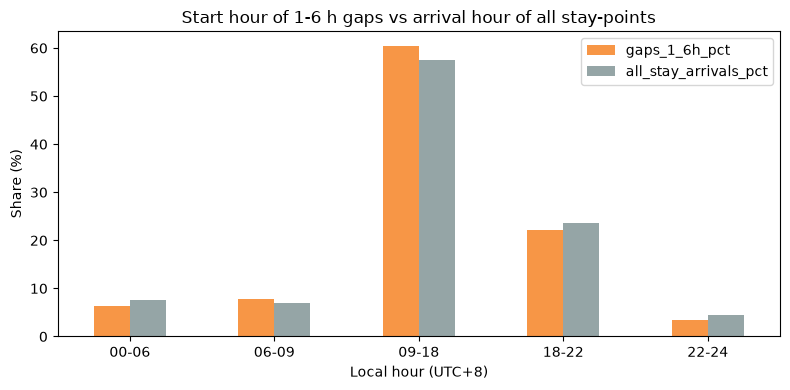

,gaps_1_6h_pct,all_stay_arrivals_pct
00-06,6.2,7.6
06-09,7.7,6.9
09-18,60.5,57.6
18-22,22.2,23.5
22-24,3.4,4.4


In [6]:
HOUR_BINS = [-1, 5, 8, 17, 21, 23]
HOUR_LABELS = ["00-06", "06-09", "09-18", "18-22", "22-24"]
gap_hours = pd.cut(gaps.loc[(gaps["gap_s"] > 3600) & (gaps["gap_s"] <= 6 * 3600), "hour_local"],
                   HOUR_BINS, labels=HOUR_LABELS)
arrival_local = pd.to_datetime(stays["arrival"]).dt.tz_localize("UTC").dt.tz_convert("Asia/Shanghai")
stay_hours = pd.cut(arrival_local.dt.hour, HOUR_BINS, labels=HOUR_LABELS)
hours = pd.DataFrame({"gaps_1_6h_pct": gap_hours.value_counts(normalize=True) * 100,
                      "all_stay_arrivals_pct": stay_hours.value_counts(normalize=True) * 100}).loc[HOUR_LABELS]
hours.to_csv(TABLE_DIR / "gap_start_hour_vs_baseline.csv")

ax = hours.plot.bar(figsize=(8, 4), rot=0, color=["#f79646", "#95a5a6"])
ax.set_xlabel("Local hour (UTC+8)")
ax.set_ylabel("Share (%)")
ax.set_title("Start hour of 1-6 h gaps vs arrival hour of all stay-points")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_gap_start_hour_vs_baseline.png", dpi=150)
plt.show()
hours.round(1)

## 6. Nếu cắt stay-point tại khoảng ngắt > X thì còn lại bao nhiêu?
Mỗi stay-point được cắt tại các khoảng ngắt > X; mảnh nào còn ≥ 30 phút thì vẫn là stay-point. `stays_lost` là số stay-point gốc không còn mảnh nào đủ 30 phút.

In [7]:
gaps_by_stay = gaps.groupby("stay_id")
rows = []
for X in [1200, 3600, 7200, 10800, 21600]:
    n_pieces, dwell_min, lost = 0, 0.0, 0
    for stay_id, s in stays.iterrows():
        g = gaps_by_stay.get_group(stay_id) if stay_id in gaps_by_stay.groups else gaps.iloc[0:0]
        g = g[g["gap_s"] > X].sort_values("t0")
        starts = [np.datetime64(s["arrival"])] + list(g["t1"].to_numpy())
        ends = list(g["t0"].to_numpy()) + [np.datetime64(s["departure"])]
        kept = [x for x in ((e - b) / np.timedelta64(1, "m") for b, e in zip(starts, ends, strict=True))
                if x >= MIN_STAY_MIN]
        n_pieces += len(kept)
        dwell_min += sum(kept)
        lost += not kept
    rows.append({"cut_at_gap_min": X // 60, "stay_points": n_pieces, "stay_points_pct": 100 * n_pieces / len(stays),
                 "dwell_time_pct": 100 * dwell_min / stays["duration_min"].sum(), "stays_lost": lost})
cut_sim = pd.DataFrame(rows)
cut_sim.to_csv(TABLE_DIR / "cut_at_gap_simulation.csv", index=False)
cut_sim.round(1)

,cut_at_gap_min,stay_points,stay_points_pct,dwell_time_pct,stays_lost
0,20,6185,48.1,27.9,7230
1,60,9115,70.9,44.7,3889
2,120,10812,84.1,60.5,2102
3,180,11742,91.3,73.2,1148
4,360,12836,99.8,98.1,25


## Kết luận

1. Khi có tín hiệu lại, người dùng chỉ cách chỗ cũ **vài chục mét** (median 24–70 m).
2. Bằng chứng "rời đi rồi quay lại" (có chuyến đi được gắn nhãn nằm trọn trong khoảng ngắt) chỉ chiếm **0.2–1.9%**, rất hiếm, và tăng nhẹ theo độ dài khoảng ngắt. Phần lớn các nhãn "giao" với khoảng ngắt thực ra là nhãn dài **bao trùm** cả khoảng ngắt (chủ yếu `walk`).
3. Giờ bắt đầu khoảng ngắt phân bố **giống** giờ đến của mọi stay-point, nên giờ trong ngày không giúp phân biệt.
4. Cắt stay-point tại khoảng ngắt 1 giờ sẽ bỏ **55%** dwell-time; cắt tại 3 giờ bỏ **27%**. Cái giá đó quá lớn so với phần ô nhiễm mà bằng chứng chỉ ra (≤ 1.9%), và dữ liệu không có điểm gãy tự nhiên nào để chọn X.

⇒ **Không cắt** stay-point tại khoảng ngắt bên trong. `StayPoint.observed_minutes` được lưu kèm `duration_minutes`, để classifier kiểm tra độ nhạy khi dùng thời gian có quan sát thay cho thời gian danh nghĩa.

In [8]:
summary = pd.DataFrame(
    [{"metric": f"trip_inside_gap_pct_{b}", "value": round(float(v), 2)} for b, v in label_evidence["trip_inside_gap_pct"].items()]
    + [{"metric": f"dwell_time_left_pct_cut_{int(r.cut_at_gap_min)}min", "value": round(float(r.dwell_time_pct), 1)}
       for r in cut_sim.itertuples()])
summary.to_csv(TABLE_DIR / "decision_summary.csv", index=False)
summary

,metric,value
0,trip_inside_gap_pct_20m-1h,0.16
1,trip_inside_gap_pct_1-2h,0.24
2,trip_inside_gap_pct_2-3h,0.73
3,trip_inside_gap_pct_3-6h,1.87
4,trip_inside_gap_pct_>6h,0.00
5,dwell_time_left_pct_cut_20min,27.90
6,dwell_time_left_pct_cut_60min,44.70
7,dwell_time_left_pct_cut_120min,60.50
8,dwell_time_left_pct_cut_180min,73.20
9,dwell_time_left_pct_cut_360min,98.10
